<a href="https://colab.research.google.com/github/Vivekshrotriya1/Capgemini-Training/blob/main/Deep_Learning_Multilayer_Neuron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Scenario :
Online Course Completion Prediction
We want to classify whether a student will complete an online course (1) or drop out (0) based on two features:

Videos Watched – number of course videos the student watched

Time Spent on Platform – total minutes spent on the learning platform

Students who watch more videos and spend more time learning are more likely to complete the course.


Dataset

    Videos_Watched  Time_Spent  Complete_Course
0                2          15                0
1                3          20                0
2                4          25                0
3                5          30                0
4                6          40                0
5                7          50                1
6                8          60                1
7                9          75                1
8               10          80                1
9                3          22                0
10               2          18                0
11               6          45                0
12               7          55                1
13               8          65                1
14               9          78                1
15               4          28                0


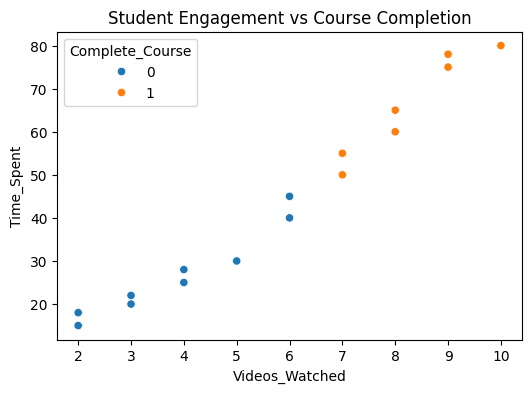


Model Summary



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3333 - loss: 0.8743 - val_accuracy: 0.6667 - val_loss: 0.7308
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.3333 - loss: 0.8698 - val_accuracy: 0.6667 - val_loss: 0.7289
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.3333 - loss: 0.8654 - val_accuracy: 0.6667 - val_loss: 0.7270
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.3333 - loss: 0.8611 - val_accuracy: 0.6667 - val_loss: 0.7251
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.4444 - loss: 0.8568 - val_accuracy: 0.6667 - val_loss: 0.7232
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.4444 - loss: 0.8524 - val_accuracy: 0.6667 - val_loss: 0.7214
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.4444 - loss: 0.8481 - val_accuracy: 0.6667 - val_loss: 0.7195
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.4444 - loss: 0.8439 - val_accuracy: 0.6667 - val_loss: 0.7177
E

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


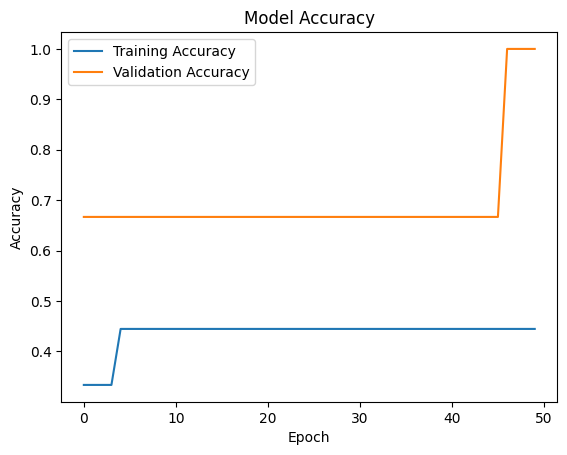

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

Student will COMPLETE the course


In [2]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense



data = {
    "Videos_Watched": [2,3,4,5,6,7,8,9,10,3,2,6,7,8,9,4],
    "Time_Spent": [15,20,25,30,40,50,60,75,80,22,18,45,55,65,78,28],
}

df = pd.DataFrame(data)

df["Complete_Course"] = ((df["Videos_Watched"] >= 7) & (df["Time_Spent"] >= 50)).astype(int)

print("\nDataset\n")
print(df)




plt.figure(figsize=(6,4))
sns.scatterplot(x="Videos_Watched", y="Time_Spent",
                hue="Complete_Course", data=df)
plt.title("Student Engagement vs Course Completion")
plt.show()




X = df[["Videos_Watched", "Time_Spent"]].values
y = df["Complete_Course"].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)




model = Sequential()


model.add(Dense(8, activation='relu', input_shape=(2,)))


model.add(Dense(4, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nModel Summary\n")
model.summary()




history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)




loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)



y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))




plt.figure()

plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()




new_student = np.array([[8,65]])

new_student = scaler.transform(new_student)

prediction = model.predict(new_student)

if prediction > 0.5:
    print("\nStudent will COMPLETE the course")
else:
    print("\nStudent will DROP OUT")